# 09a — σ_e sensitivity to fit-wavelength window

The headline σ_e(<R_e) = 268 ± 32 km/s (nb09 §6cum) was measured fitting
ppxf over the **observed-frame window 6500-7500 Å** (rest-frame
3879-4476 Å at z=0.67564) — covering Ca H+K, Hδ, G-band, Hγ, Hβ.

**Question.** How does σ_e change if we widen that window blueward? Two
things happen as we extend down:

1. We pick up extra rest-frame coverage (3300-3580 Å for the 5500-Å
   bound) — UV stellar features that early-type SPS templates may model
   imperfectly.
2. We add lower-S/N pixels at the cube's blue edge (KCWI-RL starts at
   ~5623 Å air), which can dominate or destabilize the χ².

This notebook re-runs the headline §6cum I-weighted aperture ppxf at
**R < R_e** for four windows:

| Window  | rest-frame at z=0.67564 | comment |
|---|---|---|
| 6500-7500 (nb09 headline) | 3879-4476 | reference — direct headline match |
| 6000-7500                | 3580-4476 | small blueward extension |
| 5500-7500                | 3357-4476 | clips at cube blue edge 5623 Å |
| 5000-7500                | 3357-4476 | identical to 5500 after cube clip |

Bootstrap N=100 per (window × SPS × degree) — quicker than the headline
N=500 but still useful for the relative comparison. Three SPS libraries
pooled (FSPS / EMILES / XSL) with frame-aware ppxf.

## 1. Imports + load the existing R<R_e aperture spectrum

In [1]:
import os, sys, time
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

# Reuse the headline I-weighted aperture extraction + ppxf inputs
from scripts.final_sigma_e import (
    load_setup, extract_aperture_spectrum, Z_SYSTEMIC, BOOT_SEED, WINDOW,
)
from scripts.bootstrap_ppxf import (
    setup_ppxf_inputs_from_spectrum, run_bootstrap_single_degree, C_KMS,
)
from ppxf.ppxf import ppxf

plt.rcParams['figure.facecolor'] = 'white'
plt.rc('font', family='serif', size=12)

# Robust repo-root resolution: walk up from CWD until we find CLAUDE.md.
# This handles both `cd notebooks && jupyter nbconvert ...` and
# `jupyter nbconvert notebooks/09a... --inplace` invocations.
REPO_ROOT = os.path.abspath(os.getcwd())
while REPO_ROOT != '/' and not os.path.exists(os.path.join(REPO_ROOT, 'CLAUDE.md')):
    REPO_ROOT = os.path.dirname(REPO_ROOT)
print(f"Resolved repo root: {REPO_ROOT}")

# Load cube + R_e + arc mask + I-weight map (same state nb09 uses).
# Need to chdir to repo root so that relative paths in load_setup() resolve.
_cwd_before = os.getcwd()
os.chdir(REPO_ROOT)
try:
    state = load_setup()
finally:
    os.chdir(_cwd_before)

R_E = state['R_E']
print(f"\nUsing R_e = {R_E:.3f}\" (mean of F140W + F200LP masked CoG)")

# Extract the I-weighted aperture spectrum at R<R_e with hard arc mask
flux, noise, n_kept, sn_band = extract_aperture_spectrum(
    state, r_max=R_E, mask_weight=0.0   # 0.0 = hard mask, headline behavior
)

# Apply a noise floor: ppxf requires NOISE > 0 strictly. The cube's sky-noise
# spectrum has zero-noise pixels at the blue edge (below ~5623 Å where the
# IFU has no data). Replace any nonpositive entries with 10% of the
# in-band median noise.
n_med = float(np.nanmedian(noise[noise > 0]))
n_floor = n_med * 0.1
n_zero = int(np.sum(~(noise > 0)))
noise = np.where(noise > 0, noise, n_floor)
print(f"Aperture R<R_e: {n_kept} active spaxels, S/N (in 6500-7500 Å) = {sn_band:.1f}")
print(f"Noise: median={n_med:.4g}, floor applied to {n_zero} zero/negative pixels.")
print(f"Cube wavelength range: {state['lam'][0]:.0f} - {state['lam'][-1]:.0f} Å (vacuum, observed)")

Resolved repo root: /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry
──────────────────────────────────────────────────────────────────────
§1  Load IFU cube + HST images + arc masks
──────────────────────────────────────────────────────────────────────


  IFU cube      shape=(3317, 100, 100)  pix=0.300"/spax  λ=5625-8941 Å
  F140W+mask    pix=0.080"/pix  mask=1121 pix
  F200LP+mask   pix=0.050"/pix  mask=2512 pix (arc-tuned)

§2  HST-mean center via centroid_2dg on F140W + F200LP


  F140W centroid  (RA,Dec) = (31.55610, -1.23815)
  F200LP centroid (RA,Dec) = (31.55615, -1.23823)
  |Δcentroid| = 0.357"  (FAIL)
  HST-mean → IFU sub-pixel (50.147, 54.264)

§3  R_e from masked curve-of-growth (F140W + F200LP)
  R_e(F140W masked)  = 2.168"
  R_e(F200LP masked) = 2.441"
  R_e (headline mean) = 2.305"  = 16.23 kpc
  R_e(CaHK + G-band depth) = 2.866"  (+0.561" vs headline mean)

§4  r_spax map + reprojected F200LP arc mask
  arc_spax_mask: 69 of 10000 spaxels flagged (0.69%)

Using R_e = 2.305" (mean of F140W + F200LP masked CoG)
Aperture R<R_e: 146 active spaxels, S/N (in 6500-7500 Å) = 3.8
Noise: median=0.003385, floor applied to 2 zero/negative pixels.
Cube wavelength range: 5625 - 8941 Å (vacuum, observed)


## 2. Sweep over wavelength windows × SPS × polynomial degree

For each (window, sps) pair we run ppxf at 15 polynomial degrees in
[15, 30) and bootstrap N=200 per degree. SPS pooling and per-SPS V_sys
subtraction follow the same scheme as `pool_sps()` in
`scripts/final_sigma_e.py`.

15 windows total:

- 10 unmasked obs-frame windows (`w6500_7500` … `w5500_8500`)
- 2 unmasked rest-frame windows (`wR4000_5400`, `wR3800_5400`) —
  bimodal posteriors due to z=1.302 source-emission contamination
- **3 arc-masked rest-frame windows** (`wR3800_5400_arcmask`,
  `wR3700_5400_arcmask`, `wR3500_5400_arcmask`) — same lam range as
  the unmasked variants, but with explicit hard masks at four
  contaminated bands (def-rest 3835-3855 = MgII 2796/2803 from source;
  4525-4545 = user-flagged 4534 Å feature; 5115-5135 = source [OII]
  3727 doublet sitting on Mg b; 5260-5340 = Mg b / [NeIII] 3869 cluster).
  Total mask: 212 of 2374 pixels (8.9%).

The arc-masked windows collapse the bimodal posterior into a sharp
peak (see nb09b §8 for the full diagnostic).

Wall-time at full N=200 bootstrap: ~3 hours total. Cached.

In [2]:
# Sweep configuration
# Rest-frame helpers — z=0.67564 → obs = rest * (1+z); cube max is 8941 Å
# so any obs upper > 8941 Å clips automatically inside
# setup_ppxf_inputs_from_spectrum.
_R3500_OBS = 3500.0 * (1 + Z_SYSTEMIC)   # 5864.74 Å
_R3700_OBS = 3700.0 * (1 + Z_SYSTEMIC)   # 6199.87 Å
_R3800_OBS = 3800.0 * (1 + Z_SYSTEMIC)   # 6367.43 Å
_R4000_OBS = 4000.0 * (1 + Z_SYSTEMIC)   # 6702.56 Å
_R5400_OBS = 5400.0 * (1 + Z_SYSTEMIC)   # 9048.46 Å (cube-limited to 8941)

# Empirically-identified arc-emission masks (z=1.302 source contamination
# in the deflector rest frame). Applied to windows where ARC_MASK_FLAG is True.
ARC_MASKS_REST = [
    (3835.0, 3855.0),  # Mg II 2796/2803 from source
    (4525.0, 4545.0),  # user-flagged ~4550 (source rest 3300 Å)
    (5115.0, 5135.0),  # [O II] 3727/3729 from source — sits ON Mg b
    (5260.0, 5340.0),  # Mg b / [Ne III] 3869 cluster
]

def _apply_arc_mask(goodpixels, lam_rest, masks=ARC_MASKS_REST):
    bad = np.ones(len(lam_rest), dtype=bool); bad[goodpixels] = False
    for lo, hi in masks:
        bad |= ((lam_rest >= lo) & (lam_rest <= hi))
    return np.where(~bad)[0]

# Schema: (label, (lam_obs_lo, lam_obs_hi)).  Arc-mask flag tracked
# separately in ARC_MASK_FLAG so existing 2-tuple consumers still work.
WINDOWS = [
    # ---- 12 base windows (no arc mask) ----
    ('w6500_7500', (6500.0, 7500.0)),  # nb09 headline reference
    ('w6000_7500', (6000.0, 7500.0)),
    ('w5500_7500', (5500.0, 7500.0)),
    ('w5000_7500', (5000.0, 7500.0)),
    ('w6500_8000', (6500.0, 8000.0)),
    ('w6500_8500', (6500.0, 8500.0)),
    ('w6000_8000', (6000.0, 8000.0)),
    ('w5500_8000', (5500.0, 8000.0)),
    ('w6000_8500', (6000.0, 8500.0)),
    ('w5500_8500', (5500.0, 8500.0)),
    ('wR4000_5400', (_R4000_OBS, _R5400_OBS)),
    ('wR3800_5400', (_R3800_OBS, _R5400_OBS)),
    # ---- arc-masked counterparts of every base window plus extra blueward ----
    ('w6500_7500_arcmask', (6500.0, 7500.0)),
    ('w6000_7500_arcmask', (6000.0, 7500.0)),
    ('w5500_7500_arcmask', (5500.0, 7500.0)),
    ('w5000_7500_arcmask', (5000.0, 7500.0)),
    ('w6500_8000_arcmask', (6500.0, 8000.0)),
    ('w6500_8500_arcmask', (6500.0, 8500.0)),
    ('w6000_8000_arcmask', (6000.0, 8000.0)),
    ('w5500_8000_arcmask', (5500.0, 8000.0)),
    ('w6000_8500_arcmask', (6000.0, 8500.0)),
    ('w5500_8500_arcmask', (5500.0, 8500.0)),
    ('wR4000_5400_arcmask', (_R4000_OBS, _R5400_OBS)),
    ('wR3800_5400_arcmask', (_R3800_OBS, _R5400_OBS)),
    ('wR3700_5400_arcmask', (_R3700_OBS, _R5400_OBS)),
    ('wR3500_5400_arcmask', (_R3500_OBS, _R5400_OBS)),
]

# Per-window arc-mask flag (True → apply ARC_MASKS_REST after goodpixels build)
ARC_MASK_FLAG = {wlabel: wlabel.endswith('_arcmask') for wlabel, _ in WINDOWS}

SPS_LIBS = ('fsps', 'emiles', 'xsl')
DEGREES_NB09A = np.arange(15, 30)
N_BOOT = 200

SPS_REST_MIN = {'fsps': 100.0, 'emiles': 1680.0, 'xsl': 3500.0}
PADDING = 1.05

def sps_safe_obs_min(sps):
    return SPS_REST_MIN[sps] * PADDING * (1 + Z_SYSTEMIC)

SPS_LAM_RANGE_TEMP = {
    'fsps':   (3000.0, 6000.0),
    'emiles': (3000.0, 6000.0),
    'xsl':    (3500.0, 6000.0),
}

CACHE_DIR = os.path.join(REPO_ROOT, 'results', 'nb09a_wavelength_sweep')
os.makedirs(CACHE_DIR, exist_ok=True)
print(f"Cache directory: {CACHE_DIR}")

def _ppxf_one_window(flux, noise, hdr, sps, lam_obs_range, lam_fit_range,
                     n_boot, seed_offset, arc_mask=False):
    inputs = setup_ppxf_inputs_from_spectrum(
        flux, noise, hdr,
        sps_name=sps, z=Z_SYSTEMIC,
        lam_obs_range=lam_obs_range,
        lam_fit_range=lam_fit_range,
        lam_range_temp=SPS_LAM_RANGE_TEMP[sps],
        verbose=False, frame_galaxy='auto',
    )
    if arc_mask:
        inputs['goodpixels'] = _apply_arc_mask(inputs['goodpixels'], inputs['lam_gal_rest'])
    n_pix = len(inputs['galaxy'])
    n_deg = len(DEGREES_NB09A)
    V_orig = np.zeros(n_deg); sig_orig = np.zeros(n_deg); chi2_orig = np.zeros(n_deg)
    V_boot = np.full((n_deg, n_boot), np.nan)
    sig_boot = np.full((n_deg, n_boot), np.nan)
    bf = np.zeros((n_deg, n_pix))
    for i, deg in enumerate(DEGREES_NB09A):
        pp = ppxf(
            inputs['sps'].templates, inputs['galaxy'], inputs['noise'],
            inputs['velscale'], inputs['start'],
            goodpixels=inputs['goodpixels'], plot=False, moments=2, trig=False,
            degree=int(deg), mdegree=0,
            lam=inputs['lam_gal_rest'], lam_temp=inputs['lam_temp'], quiet=True,
        )
        V_orig[i], sig_orig[i], chi2_orig[i] = pp.sol[0], pp.sol[1], pp.chi2
        bf[i] = pp.bestfit
        rb = run_bootstrap_single_degree(
            inputs, degree=int(deg), best_fit_spectrum=pp.bestfit,
            n_bootstrap=n_boot, window=WINDOW, seed=BOOT_SEED + seed_offset + i,
        )
        V_boot[i] = rb['V_samples']
        sig_boot[i] = rb['sigma_samples']
    return dict(
        sps=sps, lam_obs_range=lam_obs_range, lam_fit_range=lam_fit_range,
        n_pix=n_pix, lam_rest_min=float(inputs['lam_gal_rest'][0]),
        lam_rest_max=float(inputs['lam_gal_rest'][-1]),
        frame_galaxy=inputs['frame_galaxy'],
        V_orig=V_orig, sig_orig=sig_orig, chi2_orig=chi2_orig,
        V_boot=V_boot, sig_boot=sig_boot, bf=bf,
    )

# Run the sweep with on-disk caching so re-runs are fast.
results = {}
for w_idx, (wlabel, lr) in enumerate(WINDOWS):
    arc_mask = ARC_MASK_FLAG[wlabel]
    results[wlabel] = {}
    for sps_idx, sps in enumerate(SPS_LIBS):
        lr_eff = (max(lr[0], sps_safe_obs_min(sps)), lr[1])
        T0, T1 = int(SPS_LAM_RANGE_TEMP[sps][0]), int(SPS_LAM_RANGE_TEMP[sps][1])
        cache = os.path.join(CACHE_DIR, f'{wlabel}_{sps}_T{T0}_{T1}_N{N_BOOT}.npz')
        if os.path.exists(cache):
            d = dict(np.load(cache, allow_pickle=True))
            for k in list(d.keys()):
                if d[k].shape == ():
                    d[k] = d[k].item()
            results[wlabel][sps] = d
            am = ' [arc]' if arc_mask else ''
            print(f"  [cache] {wlabel}/{sps}: σ={d['sig_orig'].min():.0f}-{d['sig_orig'].max():.0f}  V={d['V_orig'].mean():+.0f}  npix={d['n_pix']}{am}")
            continue
        t0 = time.time()
        d = _ppxf_one_window(flux, noise, state['hdr'], sps,
                             lam_obs_range=lr_eff, lam_fit_range=lr_eff,
                             n_boot=N_BOOT,
                             seed_offset=(50_000 + 10_000 * w_idx + 100 * sps_idx),
                             arc_mask=arc_mask)
        np.savez(cache, **d)
        results[wlabel][sps] = d
        clip = '' if lr_eff[0] == lr[0] else f' (CLIP→{lr_eff[0]:.0f})'
        am_str = ' [ARC-MASKED]' if arc_mask else ''
        print(f"  {wlabel}/{sps}:  σ={d['sig_orig'].min():.0f}-{d['sig_orig'].max():.0f}  "
              f"V={d['V_orig'].mean():+.0f}  npix={d['n_pix']}  rest=[{d['lam_rest_min']:.0f},{d['lam_rest_max']:.0f}]  "
              f"({time.time()-t0:.0f}s){clip}{am_str}")

Cache directory: /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry/results/nb09a_wavelength_sweep
  [cache] w6500_7500/fsps: σ=242-271  V=-19  npix=1000
  [cache] w6500_7500/emiles: σ=261-276  V=-7  npix=1000
  [cache] w6500_7500/xsl: σ=273-285  V=-1  npix=1000
  [cache] w6000_7500/fsps: σ=199-221  V=-27  npix=1500
  [cache] w6000_7500/emiles: σ=201-227  V=-28  npix=1500
  [cache] w6000_7500/xsl: σ=232-245  V=-23  npix=1343
  [cache] w5500_7500/fsps: σ=209-237  V=-23  npix=1876
  [cache] w5500_7500/emiles: σ=204-240  V=-33  npix=1876
  [cache] w5500_7500/xsl: σ=232-245  V=-23  npix=1343
  [cache] w5000_7500/fsps: σ=209-237  V=-23  npix=1876
  [cache] w5000_7500/emiles: σ=204-240  V=-33  npix=1876
  [cache] w5000_7500/xsl: σ=232-245  V=-23  npix=1343
  [cache] w6500_8000/fsps: σ=230-243  V=-23  npix=1499
  [cache] w6500_8000/emiles: σ=243-263  V=-18  npix=1499
  [cache] w6500_8000/xsl: σ=254-271  V=-12  npix=1499
  [cache] w6500_8500/fsps: σ=226-242  V=-10  npix=2000
  [c

## 3. Pool SPS within each window and compute σ_e percentiles

Same pooling scheme as `pool_sps()`: subtract per-SPS V_sys (median V
across all bootstrap × all degrees) before concatenation, then take
percentiles of the pooled σ distribution.

In [3]:
def pool_sps_window(window_results):
    """Pool the (degrees × bootstrap) σ samples across SPS for one window."""
    pooled = []
    pooled_V = []
    per_sps = {}
    for sps, d in window_results.items():
        V = d['V_boot']
        sig = d['sig_boot']
        V_sys = float(np.nanmedian(V))
        pooled.append(sig.ravel())
        pooled_V.append((V - V_sys).ravel())
        per_sps[sps] = dict(
            sigma_p16=float(np.nanpercentile(sig, 16)),
            sigma_p50=float(np.nanpercentile(sig, 50)),
            sigma_p84=float(np.nanpercentile(sig, 84)),
            V_sys=V_sys,
            sigma_orig=d['sig_orig'].mean(),
        )
    sig_pool = np.concatenate(pooled); sig_pool = sig_pool[np.isfinite(sig_pool)]
    V_pool   = np.concatenate(pooled_V); V_pool = V_pool[np.isfinite(V_pool)]
    return dict(
        sigma_p16=float(np.percentile(sig_pool, 16)),
        sigma_p50=float(np.percentile(sig_pool, 50)),
        sigma_p84=float(np.percentile(sig_pool, 84)),
        V_p16=float(np.percentile(V_pool, 16)),
        V_p50=float(np.percentile(V_pool, 50)),
        V_p84=float(np.percentile(V_pool, 84)),
        sigma_samples=sig_pool,
        per_sps=per_sps,
    )

pool = {wlabel: pool_sps_window(results[wlabel]) for wlabel, _ in WINDOWS}

# Print the per-window summary table
print("=" * 80)
print(f"{'Window':<14}{'rest range (Å)':<20}{'σ_e p50':>10}{'-err':>8}{'+err':>8}  per-SPS σ p50")
print("-" * 80)
for wlabel, lr in WINDOWS:
    p = pool[wlabel]
    rmin = next(iter(results[wlabel].values()))['lam_rest_min']
    rmax = next(iter(results[wlabel].values()))['lam_rest_max']
    rest = f"{rmin:.0f}-{rmax:.0f}"
    err_lo = p['sigma_p50'] - p['sigma_p16']
    err_hi = p['sigma_p84'] - p['sigma_p50']
    sps_str = "  ".join(f"{sps}={p['per_sps'][sps]['sigma_p50']:.0f}" for sps in SPS_LIBS)
    print(f"{wlabel:<14}{rest:<20}{p['sigma_p50']:10.1f}{err_lo:8.1f}{err_hi:8.1f}  {sps_str}")
print("=" * 80)
print("(headline reference: σ_e(<R_e) = 268 ± 32 km/s — nb09 §6cum at default 6500-7500 obs Å, N=500)")

Window        rest range (Å)         σ_e p50    -err    +err  per-SPS σ p50
--------------------------------------------------------------------------------
w6500_7500    3880-4476                267.8    24.5    23.1  fsps=253  emiles=268  xsl=279
w6000_7500    3581-4476                219.0    20.9    21.8  fsps=207  emiles=213  xsl=237
w5500_7500    3357-4476                228.3    16.9    17.4  fsps=225  emiles=223  xsl=238
w5000_7500    3357-4476                228.1    16.7    17.4  fsps=224  emiles=223  xsl=237
w6500_8000    3880-4774                250.5    20.7    20.0  fsps=236  emiles=251  xsl=262
w6500_8500    3880-5073                245.6    16.2    16.1  fsps=239  emiles=245  xsl=252
w6000_8000    3581-4774                215.9    18.8    17.5  fsps=204  emiles=214  xsl=228
w5500_8000    3357-4774                222.1    14.8    14.3  fsps=215  emiles=222  xsl=228
w6000_8500    3581-5072                220.9    16.6    16.3  fsps=213  emiles=219  xsl=231
w5500_8500    3

### 3a. Split SPS-group pools — XSL alone vs FSPS+EMILES

The three template libraries don't have matched native LSFs:

- **XSL** ships at FWHM ≈ 0.36–0.56 Å (σ ≈ 13 km/s, fixed in velocity
  space, R ≈ 10 000) — well-matched to KCWI (σ_inst ≈ 13 km/s at rest
  4000 Å).
- **FSPS / EMILES** both ship at FWHM = 2.51 Å in the optical (σ ≈ 80
  km/s at rest 4000 Å, R ≈ 1 600). KCWI is intrinsically ~6× higher
  resolution, so ppxf's `lib.sps_lib(fwhm_gal=...)` finds
  `fwhm_temp > fwhm_gal` and skips the convolution-down step.

Pooling all three together blends a high-res (XSL) and two low-res
(FSPS/EMILES) recoveries. Splitting the pools shows whether the headline
σ_e is being driven by the templates that natively match the data.

Window        rest range              all3 σ_e        XSL only     FSPS+EMILES      ΔXSL    Δ(F+E)
--------------------------------------------------------------------------------------------------------------
w6500_7500    3880-4476          267.8 -25/+23   279.3 -19/+21   261.1 -24/+22     +11.5      -6.7
w6000_7500    3581-4476          219.0 -21/+22   236.9 -14/+16   210.2 -17/+17     +17.9      -8.8
w5500_7500    3357-4476          228.3 -17/+17   237.5 -15/+16   223.9 -16/+16      +9.2      -4.4
w5000_7500    3357-4476          228.1 -17/+17   237.2 -15/+16   223.6 -16/+16      +9.1      -4.6
w6500_8000    3880-4774          250.5 -21/+20   261.6 -15/+17   243.7 -18/+20     +11.1      -6.9
w6500_8500    3880-5073          245.6 -16/+16   252.4 -14/+14   242.1 -16/+16      +6.8      -3.5
w6000_8000    3581-4774          215.9 -19/+18   228.0 -13/+14   209.1 -17/+16     +12.1      -6.8
w5500_8000    3357-4774          222.1 -15/+14   227.7 -12/+14   218.7 -14/+15      +5.7      -3.

Saved -> /Users/rosador/Documents/AGEL/AGEL0206_kinematics_and_photometry/results/figures/nb09a_xsl_vs_fspsemiles.png


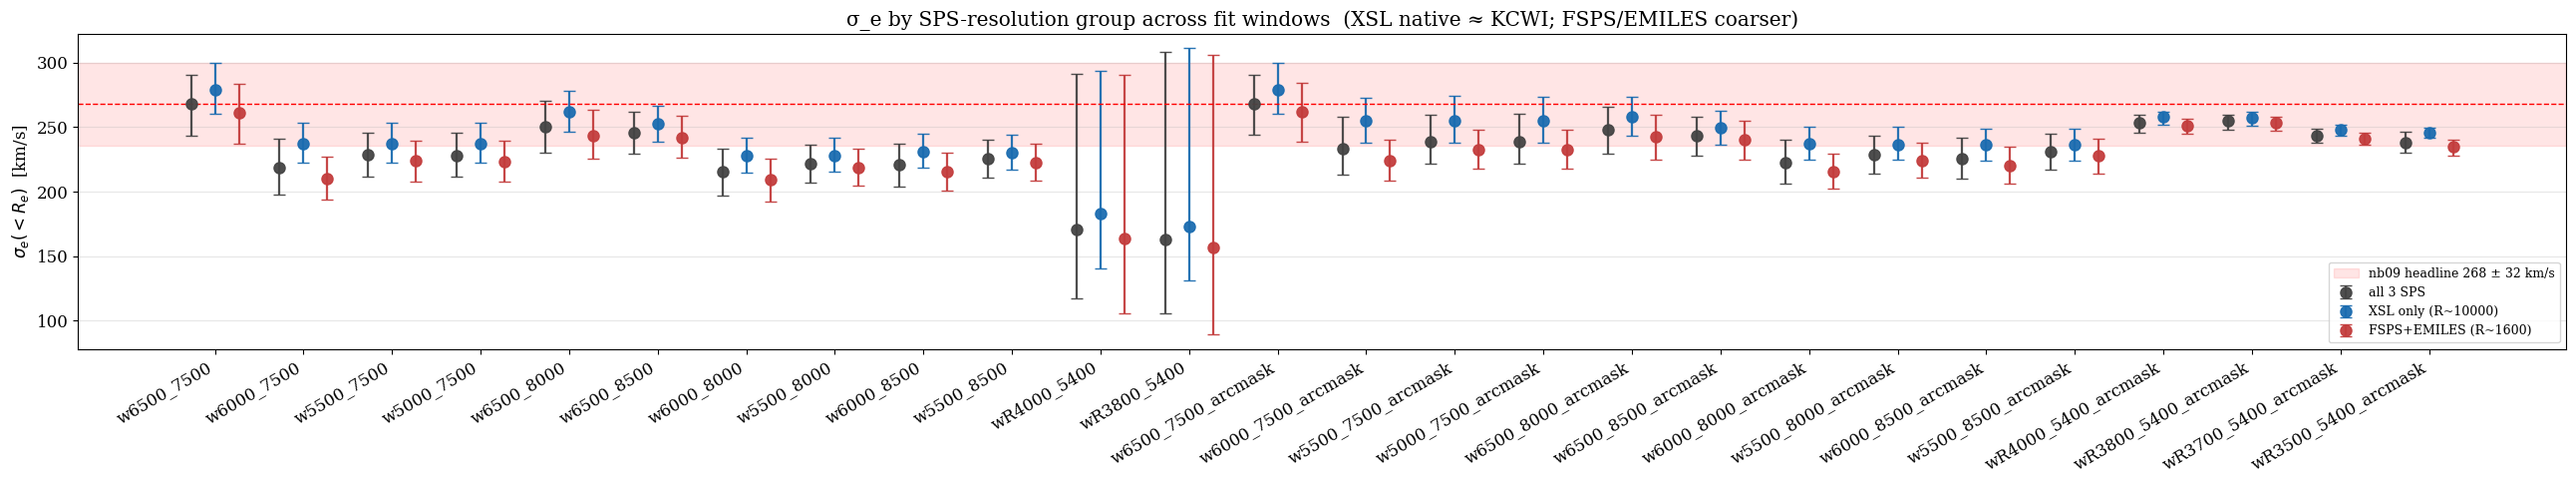

In [4]:
def pool_subset(window_results, sps_subset):
    """Pool σ samples across a subset of SPS libraries (re-uses pool_sps_window logic)."""
    sub = {sps: d for sps, d in window_results.items() if sps in sps_subset}
    if not sub:
        return None
    return pool_sps_window(sub)

SPS_GROUPS = (
    ('all3',          ('fsps', 'emiles', 'xsl')),
    ('xsl_only',      ('xsl',)),
    ('fsps_emiles',   ('fsps', 'emiles')),
)

pool_groups = {}
for wlabel, _ in WINDOWS:
    pool_groups[wlabel] = {gname: pool_subset(results[wlabel], group)
                           for gname, group in SPS_GROUPS}

# Side-by-side comparison table
print("=" * 110)
print(f"{'Window':<14}{'rest range':<16}"
      f"{'all3 σ_e':>16}{'XSL only':>16}{'FSPS+EMILES':>16}"
      f"{'ΔXSL':>10}{'Δ(F+E)':>10}")
print("-" * 110)
for wlabel, _ in WINDOWS:
    rmin = next(iter(results[wlabel].values()))['lam_rest_min']
    rmax = next(iter(results[wlabel].values()))['lam_rest_max']
    rest = f"{rmin:.0f}-{rmax:.0f}"
    p_all = pool_groups[wlabel]['all3']
    p_xsl = pool_groups[wlabel]['xsl_only']
    p_fe  = pool_groups[wlabel]['fsps_emiles']
    def fmt(p):
        lo, hi = p['sigma_p50']-p['sigma_p16'], p['sigma_p84']-p['sigma_p50']
        return f"{p['sigma_p50']:6.1f} -{lo:.0f}/+{hi:.0f}"
    d_xsl = p_xsl['sigma_p50'] - p_all['sigma_p50']
    d_fe  = p_fe['sigma_p50']  - p_all['sigma_p50']
    print(f"{wlabel:<14}{rest:<16}{fmt(p_all):>16}{fmt(p_xsl):>16}{fmt(p_fe):>16}"
          f"{d_xsl:>+10.1f}{d_fe:>+10.1f}")
print("=" * 110)
print("(ΔXSL = XSL-only median minus all-3 median; Δ(F+E) = FSPS+EMILES median minus all-3.)")
print(f"(headline reference 6500-7500: σ_e(<R_e) all3=268 ± 32 km/s — nb09 §6cum, N=500)")

# Figure — grouped bars per window for the three SPS-group pools
fig, ax = plt.subplots(figsize=(max(10, 1.0*len(WINDOWS)), 5.0))
xs = np.arange(len(WINDOWS))
width = 0.27
group_colors = {'all3':'#444', 'xsl_only':'#1b6cb0', 'fsps_emiles':'#c33d3d'}
group_labels = {'all3':'all 3 SPS', 'xsl_only':'XSL only (R~10000)',
                'fsps_emiles':'FSPS+EMILES (R~1600)'}
for k, (gname, _) in enumerate(SPS_GROUPS):
    p50s   = [pool_groups[w][gname]['sigma_p50'] for w, _ in WINDOWS]
    err_lo = [pool_groups[w][gname]['sigma_p50'] - pool_groups[w][gname]['sigma_p16'] for w, _ in WINDOWS]
    err_hi = [pool_groups[w][gname]['sigma_p84'] - pool_groups[w][gname]['sigma_p50'] for w, _ in WINDOWS]
    ax.errorbar(xs + (k-1)*width, p50s, yerr=[err_lo, err_hi],
                fmt='o', ms=8, capsize=4, lw=1.6,
                color=group_colors[gname], label=group_labels[gname], alpha=0.95)
ax.axhspan(268-32, 268+32, color='red', alpha=0.10,
           label='nb09 headline 268 ± 32 km/s')
ax.axhline(268, color='red', ls='--', lw=1.0)
ax.set_xticks(xs)
ax.set_xticklabels([w for w, _ in WINDOWS], rotation=30, ha='right')
ax.set_ylabel(r'$\sigma_e(<R_e)$  [km/s]')
ax.set_title("σ_e by SPS-resolution group across fit windows  (XSL native ≈ KCWI; FSPS/EMILES coarser)")
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
fig_path = os.path.join(REPO_ROOT, 'results', 'figures', 'nb09a_xsl_vs_fspsemiles.png')
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
fig.savefig(fig_path, dpi=140)
print(f"Saved -> {fig_path}")
plt.show()

## 4. Diagnostic plots

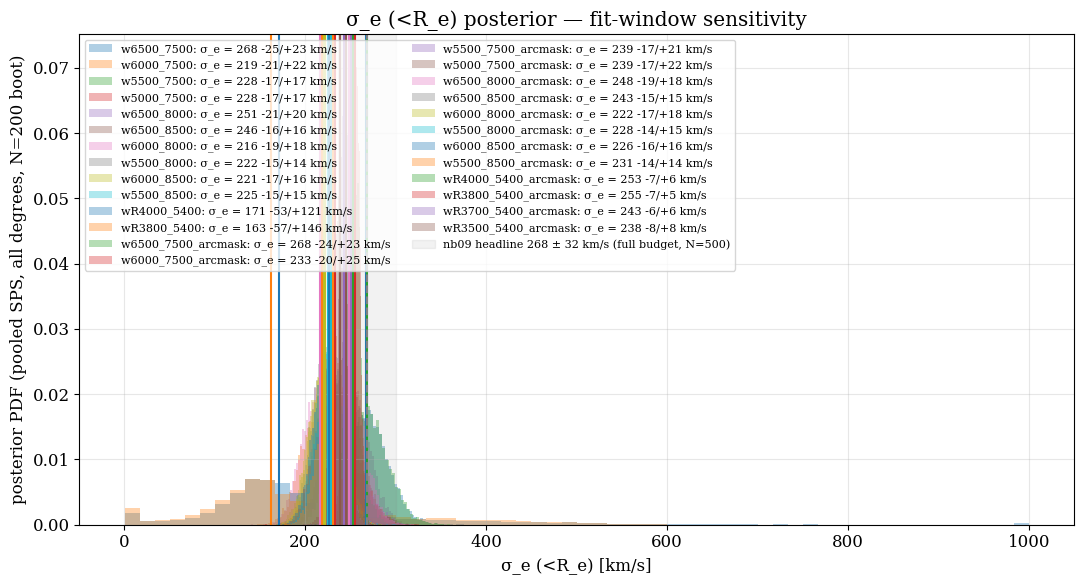

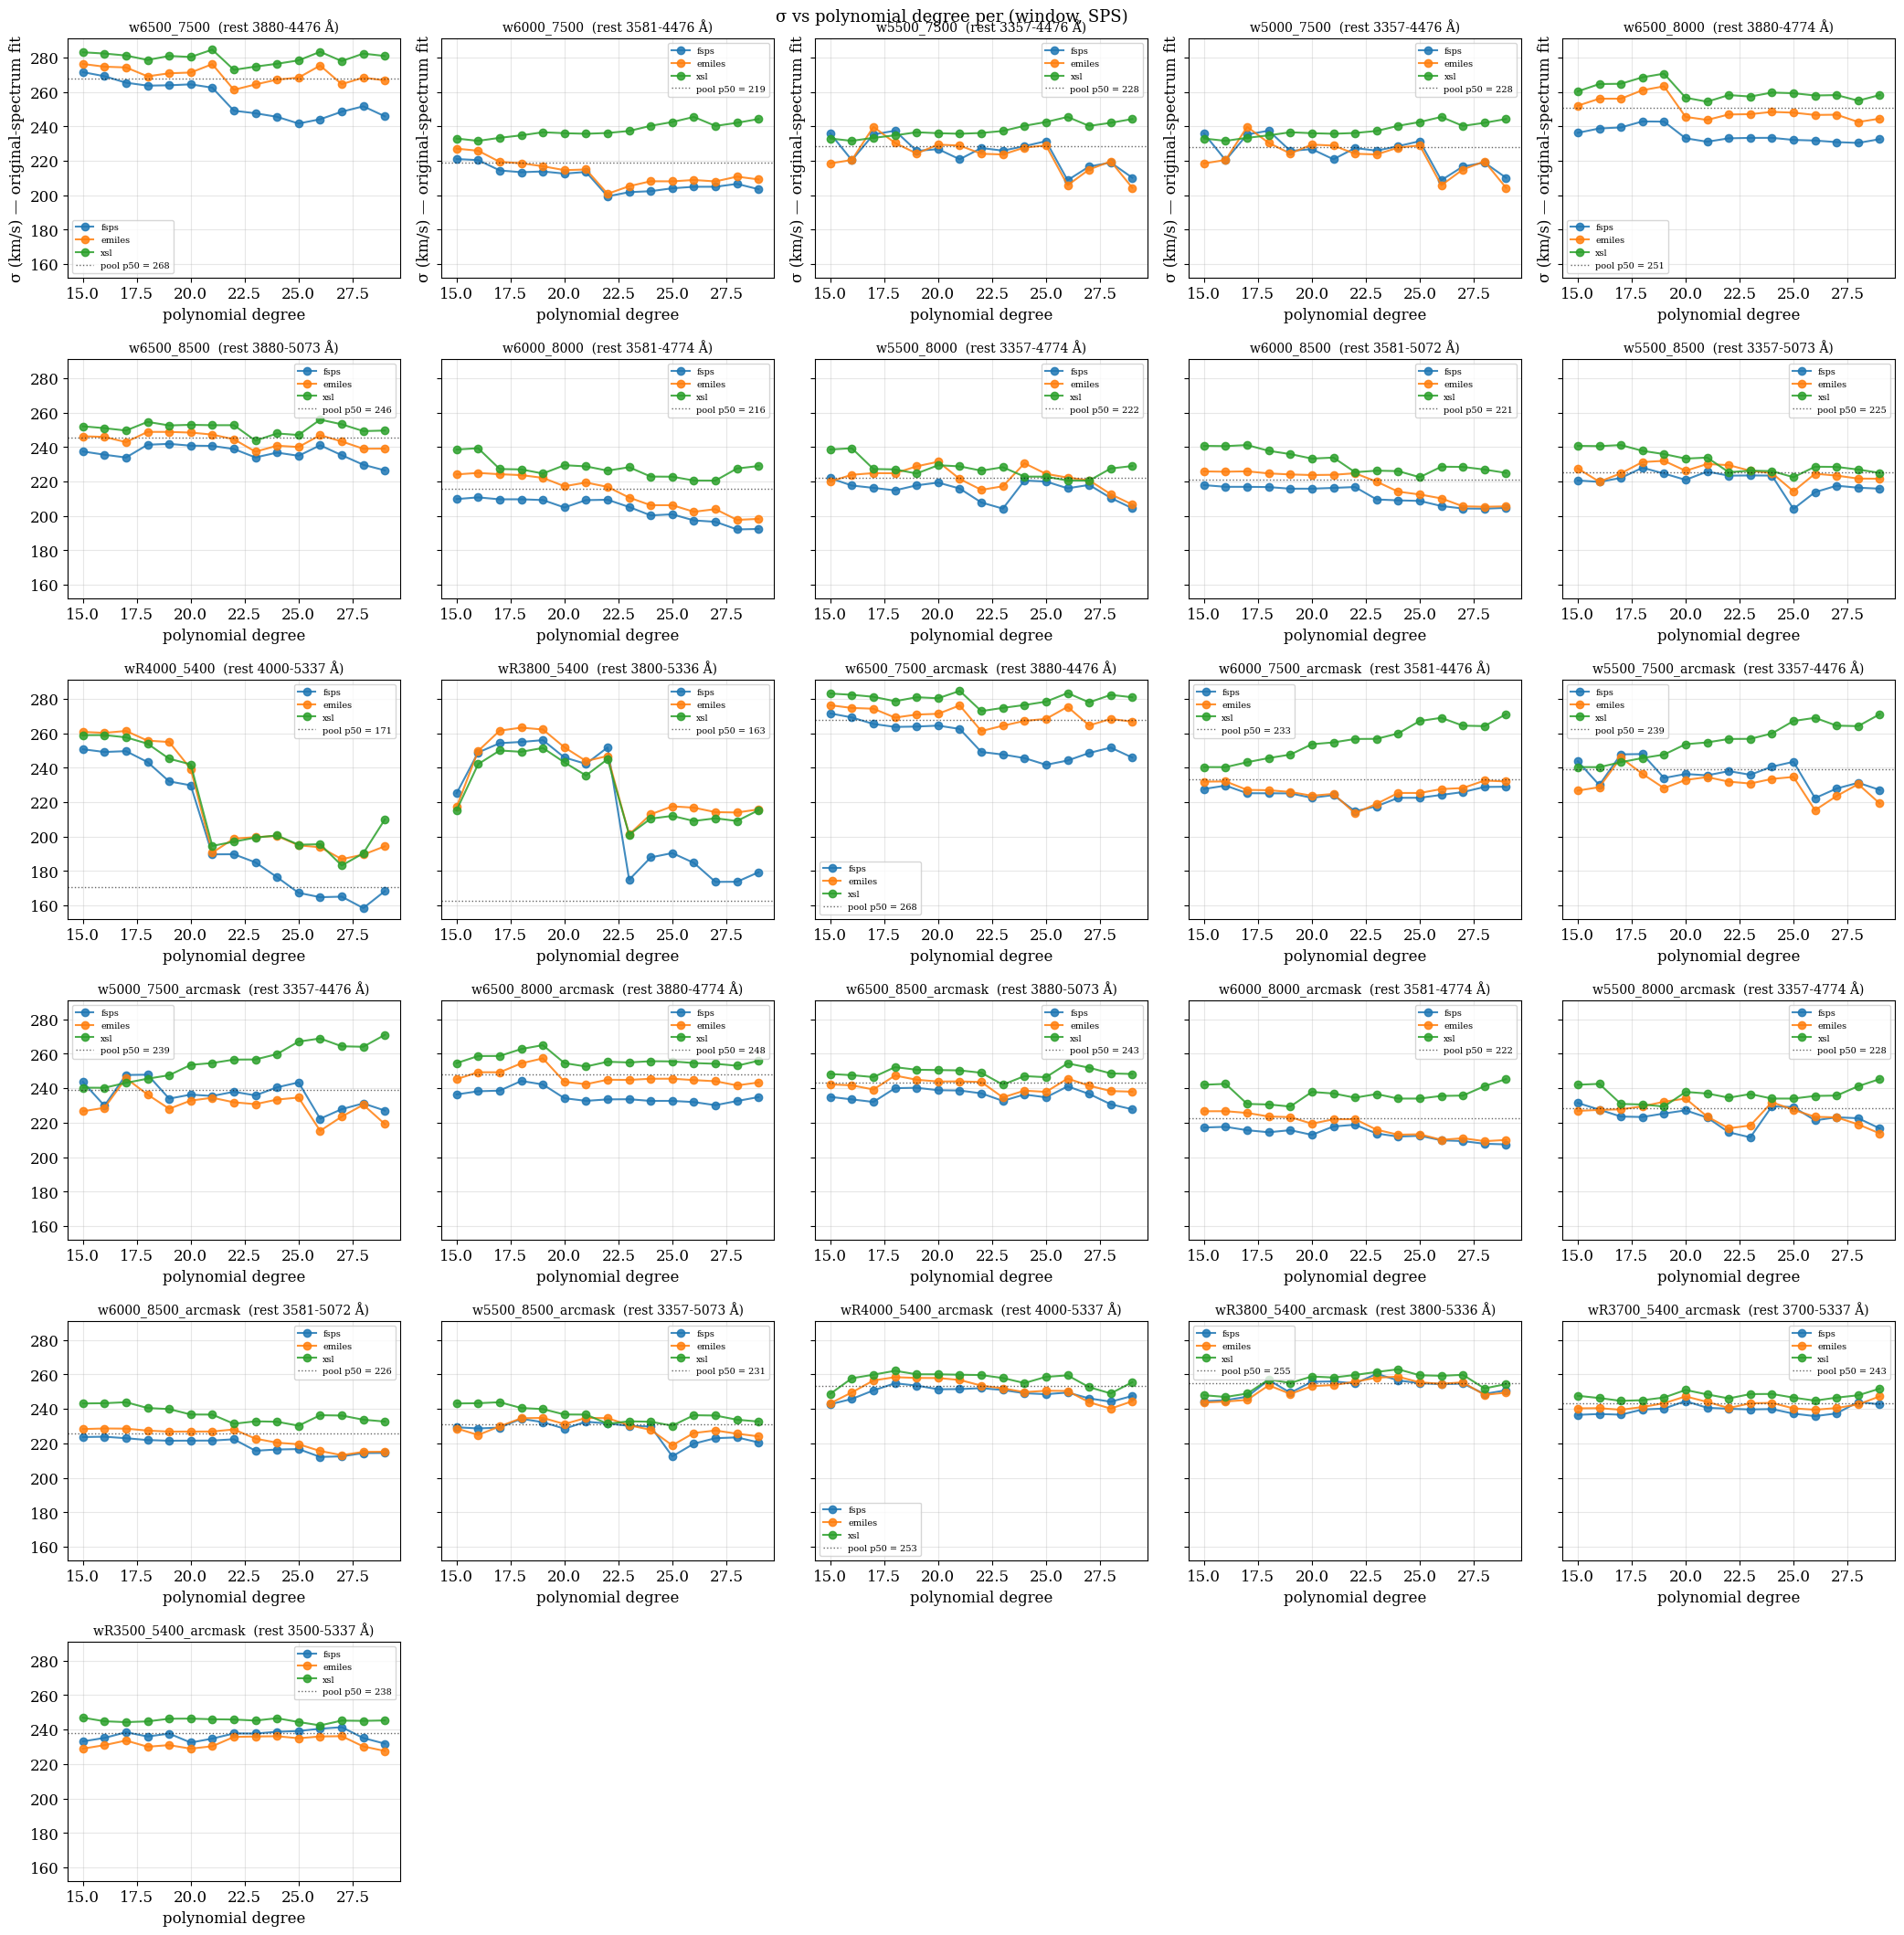

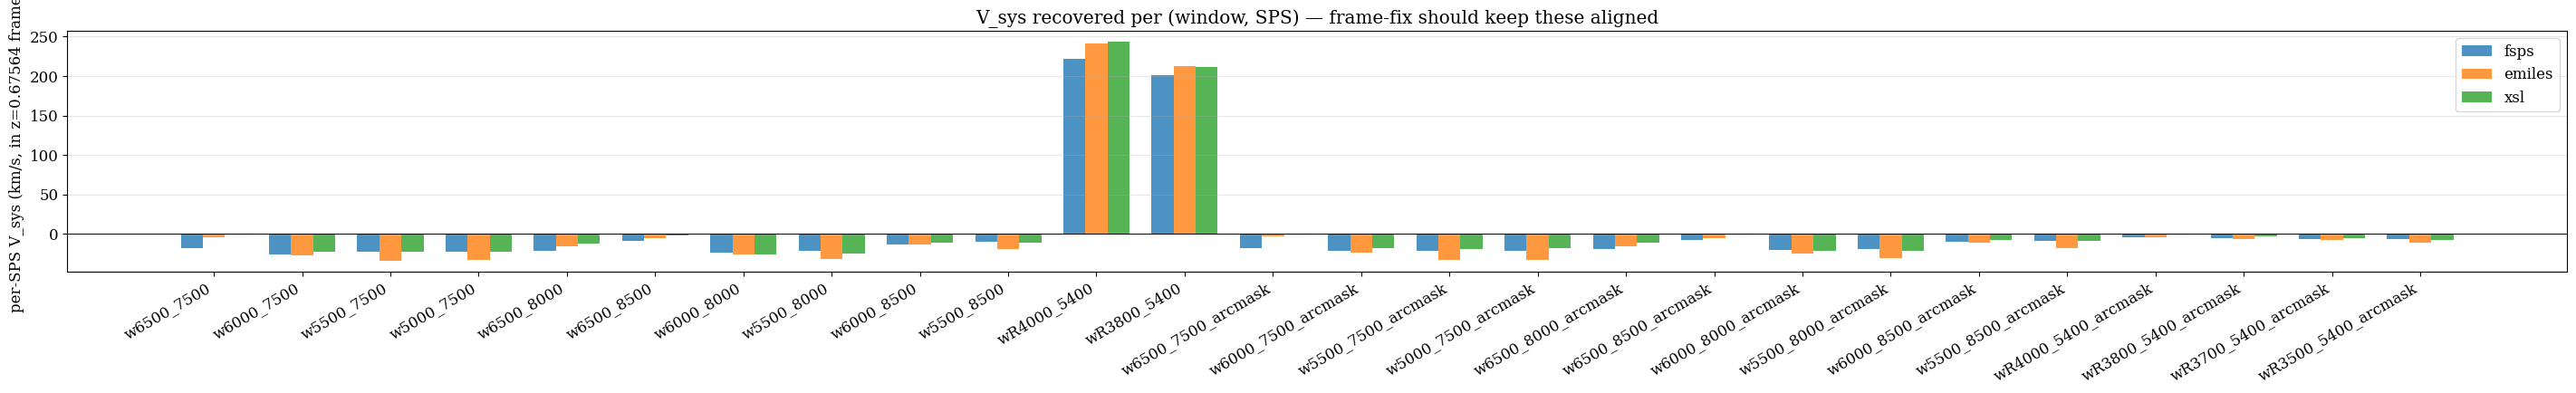

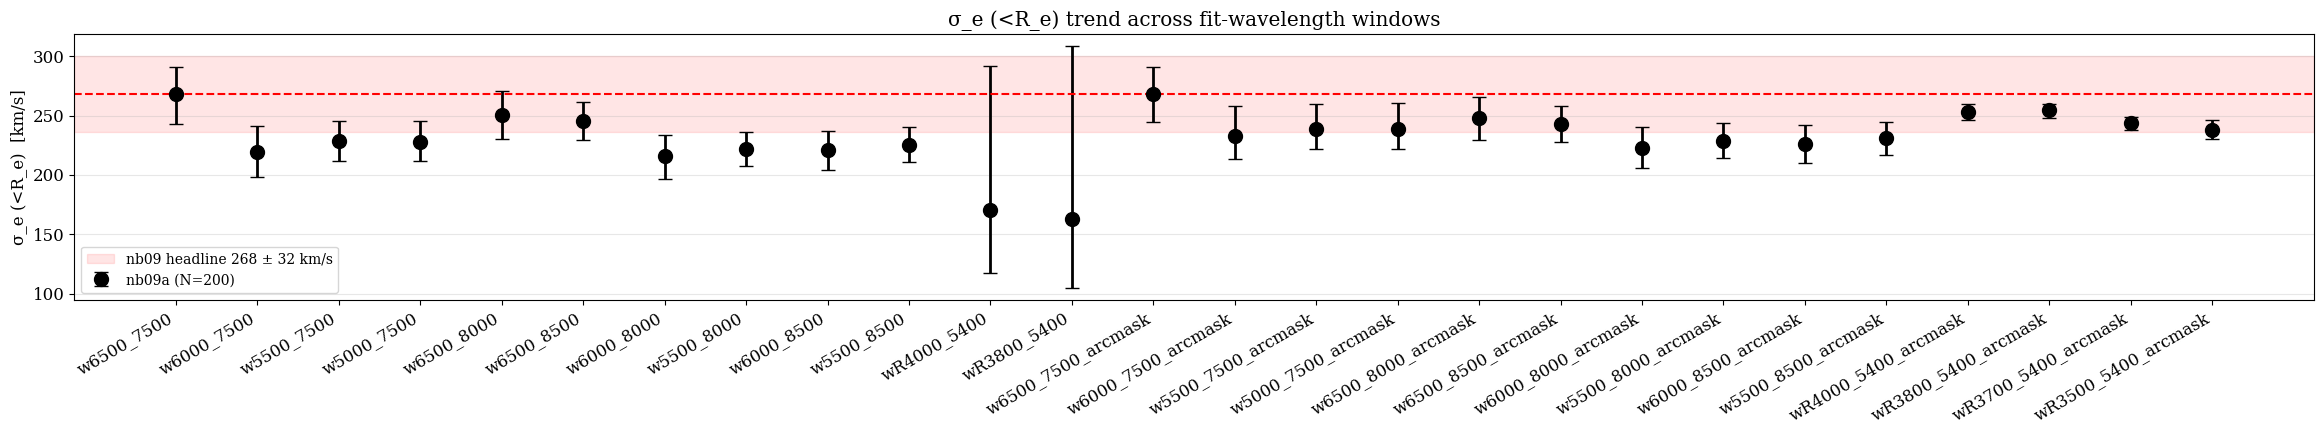

In [5]:
# Figure 1 — pooled σ_e posterior per window (overlaid)
import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(11, 6))
cmap = cm.tab10
colors = {wlabel: cmap(i % 10) for i, (wlabel, _) in enumerate(WINDOWS)}
for wlabel, _ in WINDOWS:
    p = pool[wlabel]
    s = p['sigma_samples']
    ax.hist(s, bins=60, density=True, alpha=0.35, color=colors[wlabel],
            label=f"{wlabel}: σ_e = {p['sigma_p50']:.0f}"
                  f" -{p['sigma_p50']-p['sigma_p16']:.0f}/+{p['sigma_p84']-p['sigma_p50']:.0f} km/s")
    ax.axvline(p['sigma_p50'], color=colors[wlabel], lw=1.5)
ax.axvspan(268-32, 268+32, color='gray', alpha=0.10,
           label='nb09 headline 268 ± 32 km/s (full budget, N=500)')
ax.axvline(268, color='gray', ls='--', lw=1.5)
ax.set_xlabel('σ_e (<R_e) [km/s]')
ax.set_ylabel(f'posterior PDF (pooled SPS, all degrees, N={N_BOOT} boot)')
ax.set_title("σ_e (<R_e) posterior — fit-window sensitivity")
ax.legend(fontsize=8, ncol=2, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Figure 2 — σ vs polynomial degree per (window, sps) — diagnoses polynomial saturation
ncols = min(5, len(WINDOWS))
nrows = int(np.ceil(len(WINDOWS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.6*nrows), sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax, (wlabel, _) in zip(axes, WINDOWS):
    for sps_idx, sps in enumerate(SPS_LIBS):
        d = results[wlabel][sps]
        ax.plot(DEGREES_NB09A, d['sig_orig'],
                marker='o', lw=1.5, label=f"{sps}", alpha=0.85)
    ax.axhline(pool[wlabel]['sigma_p50'], color='k', ls=':', lw=1, alpha=0.6,
               label=f"pool p50 = {pool[wlabel]['sigma_p50']:.0f}")
    ax.set_xlabel('polynomial degree')
    ax.set_title(f'{wlabel}  (rest {results[wlabel][SPS_LIBS[0]]["lam_rest_min"]:.0f}-'
                 f'{results[wlabel][SPS_LIBS[0]]["lam_rest_max"]:.0f} Å)',
                 fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
for ax in axes[len(WINDOWS):]:
    ax.set_visible(False)
for ax in axes[:ncols]:
    ax.set_ylabel('σ (km/s) — original-spectrum fit')
fig.suptitle('σ vs polynomial degree per (window, SPS)', fontsize=13)
plt.tight_layout()
plt.show()

# Figure 3 — V_sys per (window, sps): does extending blueward shift the recovered velocity?
fig, ax = plt.subplots(figsize=(max(10, 1.1*len(WINDOWS)), 4.5))
xs = np.arange(len(WINDOWS))
width = 0.25
for k, sps in enumerate(SPS_LIBS):
    Vs = [pool[wlabel]['per_sps'][sps]['V_sys'] for wlabel, _ in WINDOWS]
    ax.bar(xs + (k - 1) * width, Vs, width, label=sps, alpha=0.8)
ax.set_xticks(xs)
ax.set_xticklabels([w for w, _ in WINDOWS], rotation=30, ha='right')
ax.set_ylabel('per-SPS V_sys (km/s, in z=0.67564 frame)')
ax.set_title("V_sys recovered per (window, SPS) — frame-fix should keep these aligned")
ax.axhline(0, color='k', lw=0.7)
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Figure 4 — σ_e p50 vs window (one-line summary)
fig, ax = plt.subplots(figsize=(max(8, 0.9*len(WINDOWS)), 4.5))
xs = np.arange(len(WINDOWS))
p50s = [pool[w]['sigma_p50'] for w, _ in WINDOWS]
err_lo = [pool[w]['sigma_p50'] - pool[w]['sigma_p16'] for w, _ in WINDOWS]
err_hi = [pool[w]['sigma_p84'] - pool[w]['sigma_p50'] for w, _ in WINDOWS]
ax.errorbar(xs, p50s, yerr=[err_lo, err_hi], fmt='o', ms=10, capsize=5,
            color='black', lw=2, label=f'nb09a (N={N_BOOT})')
ax.axhspan(268-32, 268+32, color='red', alpha=0.10,
           label='nb09 headline 268 ± 32 km/s')
ax.axhline(268, color='red', ls='--', lw=1.5)
ax.set_xticks(xs)
ax.set_xticklabels([w for w, _ in WINDOWS], rotation=30, ha='right')
ax.set_ylabel('σ_e (<R_e)  [km/s]')
ax.set_title("σ_e (<R_e) trend across fit-wavelength windows")
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 5. Best-fit overlay — sanity check that the wider windows actually fit the extra blueward data

Reference SSP: FSPS, age=10.00 Gyr, [Z/H]=0.00, broadened to σ=250 km/s (σ_pix=6.08, velscale=41.1 km/s/pix)


/var/folders/mm/fytlrh2s5nx_x7cvgsdllc2h0000gr/T/ipykernel_54180/2447376068.py:119: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(lo - 0.5*dlam, hi + 0.5*dlam,


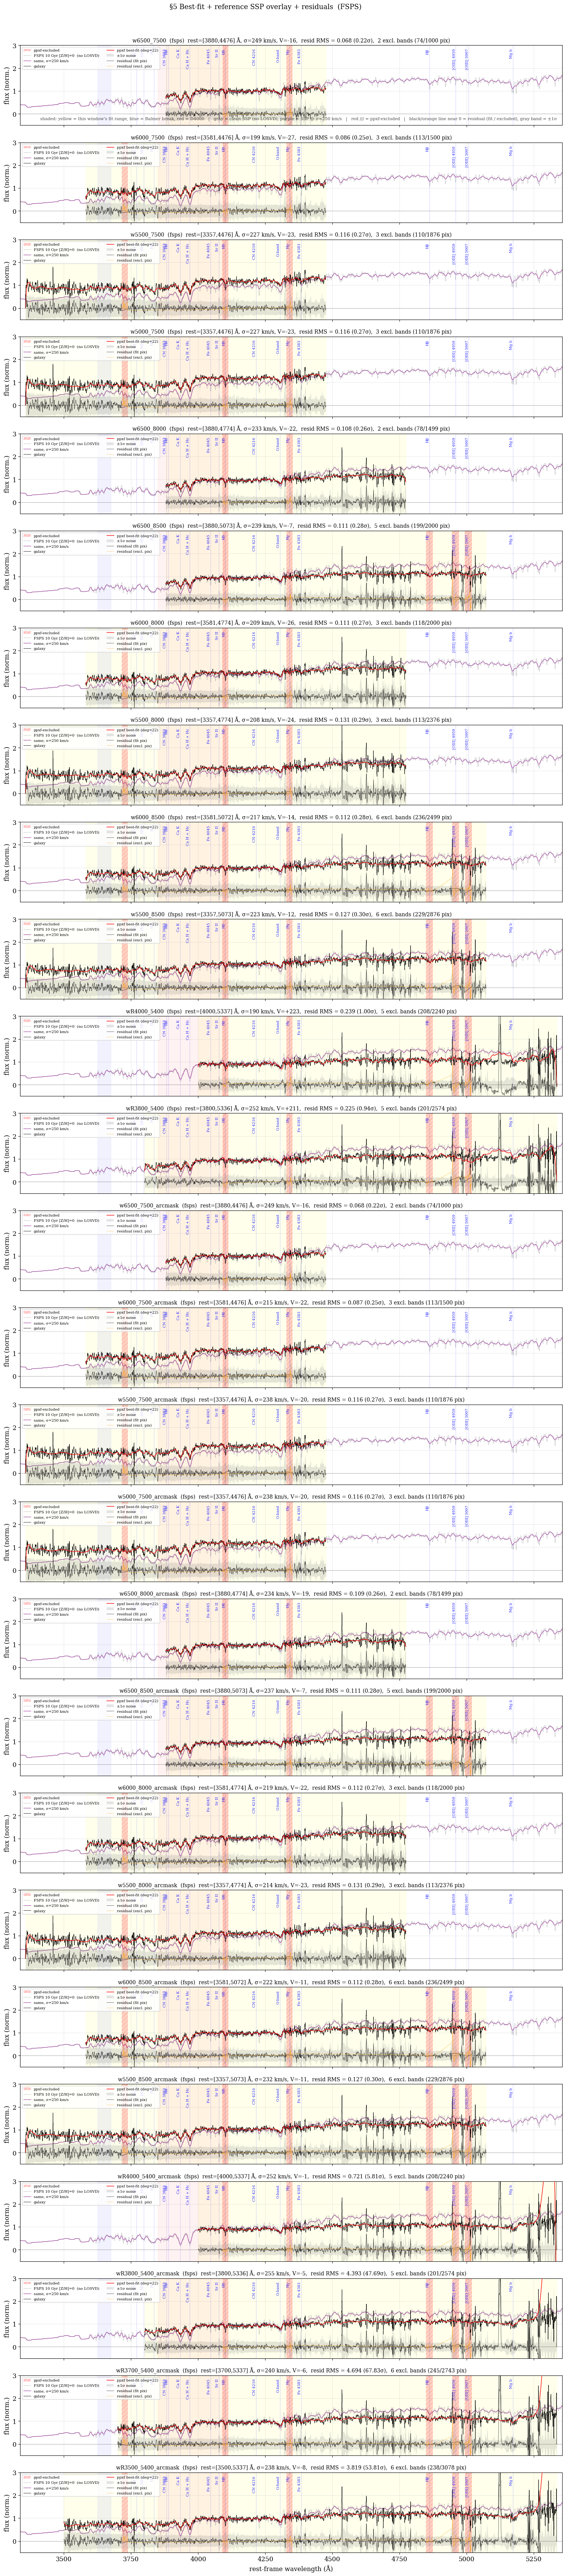

In [6]:
# Pick a representative degree (median of DEGREES_NB09A) and overplot the
# best-fit galaxy + ppxf model for each window. ALL PANELS SHARE x AXIS so
# the additional blueward data each wider cut adds is visible at a glance.
# We also overlay a clean FSPS SSP (10 Gyr, [Z/H]=0) — both unbroadened and
# σ=250 km/s LOSVD-convolved — as a high-S/N "what to expect" reference.
# Residuals (galaxy - bestfit) are plotted in the SAME panel near y=0.
from scipy.ndimage import gaussian_filter1d

deg_idx = len(DEGREES_NB09A) // 2
deg_show = int(DEGREES_NB09A[deg_idx])
sps_show = 'fsps'

# Stellar absorption features useful as anchors for early-type galaxies.
# Extended for the wider redward windows: Hβ, Mg b, [OIII] (the latter
# usually masked by ppxf as a gas line).
ABS_LINES = {
    'H11':       3770.63,
    'H10':       3797.91,
    'H9':        3835.39,
    'CN 3883':   3883.0,
    'H8':        3889.06,
    'Ca K':      3933.66,
    'Ca H + Hε': 3968.5,
    'Hδ':        4101.74,
    'Sr II':     4077.71,
    'Fe 4045':   4045.81,
    'CN 4216':   4216.0,
    'G-band':    4304.40,
    'Hγ':        4340.47,
    'Fe 4383':   4383.55,
    'Hβ':        4861.33,
    '[OIII] 4959': 4958.91,
    '[OIII] 5007': 5006.84,
    'Mg b':      5172.0,
}
BREAKS = [
    ('Balmer break', 3625, 3675, '#88f'),
    ('D4000',        3850, 4100, '#f88'),
]

def goodpix_to_excluded_bands(lam_rest, goodpixels):
    """ppxf goodpixels → list of (lo, hi) bands EXCLUDED from the fit."""
    n = len(lam_rest)
    bad = np.setdiff1d(np.arange(n), goodpixels)
    if bad.size == 0:
        return []
    bands = []
    start = bad[0]; prev = bad[0]
    for idx in bad[1:]:
        if idx == prev + 1:
            prev = idx; continue
        bands.append((float(lam_rest[start]), float(lam_rest[prev])))
        start = idx; prev = idx
    bands.append((float(lam_rest[start]), float(lam_rest[prev])))
    return bands

# Common x range — widens automatically when redder windows are added.
all_rests = [(results[w][sps_show]['lam_rest_min'],
              results[w][sps_show]['lam_rest_max']) for w, _ in WINDOWS]
xmin = min(r[0] for r in all_rests) - 20
xmax = max(r[1] for r in all_rests) + 20

# Reference SSP (build on the WIDEST window so the reference covers all panels)
widest_w = max(WINDOWS,
               key=lambda wl: (results[wl[0]][sps_show]['lam_rest_max']
                               - results[wl[0]][sps_show]['lam_rest_min']))[0]
d_widest = results[widest_w][sps_show]
inp_ref = setup_ppxf_inputs_from_spectrum(
    flux, noise, state['hdr'], sps_name=sps_show, z=Z_SYSTEMIC,
    lam_obs_range=d_widest['lam_obs_range'],
    lam_fit_range=d_widest['lam_fit_range'],
    lam_range_temp=SPS_LAM_RANGE_TEMP[sps_show],
    verbose=False, frame_galaxy='auto',
)
sps_ref = inp_ref['sps']
ages_yr  = sps_ref.age_grid[:, 0]
metals   = sps_ref.metal_grid[0, :]
age_idx   = int(np.argmin(np.abs(ages_yr - 10.0)))
metal_idx = int(np.argmin(np.abs(metals - 0.0)))
ssp_unbroad = sps_ref.templates[:, age_idx, metal_idx].astype(float)
ssp_lam = sps_ref.lam_temp.astype(float)
ssp_unbroad /= np.median(ssp_unbroad)
sigma_kms = 250.0
sigma_pix = sigma_kms / inp_ref['velscale']
ssp_broad = gaussian_filter1d(ssp_unbroad, sigma=sigma_pix, mode='nearest')

print(f"Reference SSP: FSPS, age={ages_yr[age_idx]:.2f} Gyr, "
      f"[Z/H]={metals[metal_idx]:.2f}, broadened to σ={sigma_kms:.0f} km/s "
      f"(σ_pix={sigma_pix:.2f}, velscale={inp_ref['velscale']:.1f} km/s/pix)")

fig, axes = plt.subplots(len(WINDOWS), 1, figsize=(16, 2.6*len(WINDOWS)),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes)
for ax, (wlabel, _) in zip(axes, WINDOWS):
    d = results[wlabel][sps_show]
    inp = setup_ppxf_inputs_from_spectrum(
        flux, noise, state['hdr'], sps_name=sps_show, z=Z_SYSTEMIC,
        lam_obs_range=d['lam_obs_range'], lam_fit_range=d['lam_fit_range'],
        lam_range_temp=SPS_LAM_RANGE_TEMP[sps_show],
        verbose=False, frame_galaxy='auto',
    )
    lam_rest = inp['lam_gal_rest']
    galaxy = inp['galaxy']
    noise_arr = inp['noise']
    bestfit = d['bf'][deg_idx]
    goodpix = inp['goodpixels']
    good_mask = np.zeros_like(lam_rest, dtype=bool)
    good_mask[goodpix] = True

    # Background bands
    ax.axvspan(lam_rest[0], lam_rest[-1], color='lightyellow', alpha=0.6, zorder=0)
    for nm, lo, hi, c in BREAKS:
        ax.axvspan(lo, hi, color=c, alpha=0.10, zorder=0)

    # ppxf-excluded bands
    excluded = goodpix_to_excluded_bands(lam_rest, goodpix)
    dlam = float(lam_rest[1] - lam_rest[0]) if len(lam_rest) > 1 else 0.0
    for k, (lo, hi) in enumerate(excluded):
        ax.axvspan(lo - 0.5*dlam, hi + 0.5*dlam,
                   color='red', alpha=0.18, hatch='///',
                   edgecolor='darkred', linewidth=0.0, zorder=2,
                   label='ppxf-excluded' if k == 0 else None)

    # Reference SSP
    cont_med = float(np.median(galaxy))
    ax.plot(ssp_lam, ssp_unbroad * cont_med, color='gray', lw=0.7, alpha=0.45,
            ls='-', label='FSPS 10 Gyr [Z/H]=0  (no LOSVD)', zorder=1)
    ax.plot(ssp_lam, ssp_broad * cont_med, color='purple', lw=0.9, alpha=0.7,
            ls='-', label='same, σ=250 km/s', zorder=1)

    # Spectrum + best fit
    ax.step(lam_rest, galaxy, color='k', lw=0.6, label='galaxy', zorder=3)
    ax.plot(lam_rest, bestfit, color='r', lw=1.0,
            label=f'ppxf best-fit (deg={deg_show})', zorder=4)

    # Residuals on same panel — natural-flux units, around y=0.
    resid = galaxy - bestfit
    noise_used = np.where(noise_arr > 0, noise_arr, np.nanmedian(noise_arr))
    ax.fill_between(lam_rest, -noise_used, +noise_used,
                    color='gray', alpha=0.20, lw=0, zorder=2,
                    label='±1σ noise')
    ax.axhline(0, color='k', lw=0.5, alpha=0.4, zorder=2)
    ax.plot(lam_rest[good_mask],  resid[good_mask],
            color='black',  lw=0.5, alpha=0.85, label='residual (fit pix)', zorder=5)
    ax.plot(lam_rest[~good_mask], resid[~good_mask],
            color='orange', lw=0.5, alpha=0.7,  label='residual (excl. pix)', zorder=5)

    # Per-line markers
    for lname, lwl in ABS_LINES.items():
        ax.axvline(lwl, color='blue', ls=':', alpha=0.5, lw=0.7, zorder=2)
        ax.text(lwl, 2.85, lname, fontsize=7, rotation=90,
                color='blue', alpha=0.85, ha='right', va='top')

    n_excl_pix = len(lam_rest) - len(goodpix)
    rms_norm = float(np.sqrt(np.mean(resid[good_mask]**2))) if good_mask.any() else np.nan
    rms_sigma = (float(np.sqrt(np.mean((resid[good_mask] / noise_used[good_mask])**2)))
                 if good_mask.any() else np.nan)
    ax.set_ylabel('flux (norm.)')
    ax.set_title(f"{wlabel}  ({sps_show})  rest=[{lam_rest[0]:.0f},{lam_rest[-1]:.0f}] Å, "
                 f"σ={d['sig_orig'][deg_idx]:.0f} km/s, V={d['V_orig'][deg_idx]:+.0f},  "
                 f"resid RMS = {rms_norm:.3f} ({rms_sigma:.2f}σ),  "
                 f"{len(excluded)} excl. bands ({n_excl_pix}/{len(lam_rest)} pix)",
                 fontsize=10)
    ax.legend(fontsize=7, loc='upper left', ncol=2)
    ax.grid(alpha=0.25)
    ax.set_xlim(xmin, xmax)

axes[0].text(0.99, 0.05,
             "shaded: yellow = this window's fit range, "
             "blue = Balmer break, red = D4000   |   "
             "gray = clean SSP (no LOSVD), purple = SSP @ σ=250 km/s   |   "
             "red /// = ppxf-excluded   |   "
             "black/orange line near 0 = residual (fit / excluded), gray band = ±1σ",
             transform=axes[0].transAxes, ha='right', va='bottom',
             fontsize=8, alpha=0.7)
axes[-1].set_xlabel('rest-frame wavelength (Å)')
axes[-1].set_ylim(-0.5, 3)
axes[-1].set_yscale('linear')
fig.suptitle(f"§5 Best-fit + reference SSP overlay + residuals  ({sps_show.upper()})",
             fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

## 6. Save summary + verdict

In [7]:
# Compare each window against the nb09 headline reference (6500-7500).
ref_p = pool['w6500_7500']
print("=" * 70)
print(f"FIT-WINDOW SENSITIVITY — σ_e (<R_e), pooled SPS, N={N_BOOT} boot")
print("=" * 70)
print(f"  Reference 6500-7500 σ_e = {ref_p['sigma_p50']:.1f} "
      f"-{ref_p['sigma_p50']-ref_p['sigma_p16']:.1f}/+{ref_p['sigma_p84']-ref_p['sigma_p50']:.1f} km/s")
print(f"  (nb09 headline at this window with N=500: 268 ± 32 km/s)\n")
for wlabel, _ in WINDOWS:
    if wlabel == 'w6500_7500':
        continue
    p = pool[wlabel]
    dsig = p['sigma_p50'] - ref_p['sigma_p50']
    typ_err = 0.5 * (p['sigma_p84'] - p['sigma_p16'])
    n_sigma = abs(dsig) / typ_err
    verdict = "consistent" if n_sigma < 1.0 else f"DEVIATES at {n_sigma:.1f}σ"
    print(f"  {wlabel:<14}  σ_e = {p['sigma_p50']:6.1f} "
          f"(-{p['sigma_p50']-p['sigma_p16']:.1f}/+{p['sigma_p84']-p['sigma_p50']:.1f})  "
          f"  Δ vs 6500 = {dsig:+.1f} km/s  [{verdict}]")
print("=" * 70)

# Save summary
out_path = os.path.join(REPO_ROOT, 'results', 'sigma_e_window_sweep_09a.npz')
saved = dict(
    windows=np.array([w for w, _ in WINDOWS]),
    window_ranges=np.array([list(r) for _, r in WINDOWS]),
    sps_libs=np.array(SPS_LIBS),
    degrees=DEGREES_NB09A,
    n_bootstrap=N_BOOT,
    sigma_p50=np.array([pool[w]['sigma_p50'] for w, _ in WINDOWS]),
    sigma_p16=np.array([pool[w]['sigma_p16'] for w, _ in WINDOWS]),
    sigma_p84=np.array([pool[w]['sigma_p84'] for w, _ in WINDOWS]),
    R_E=R_E,
    z_systemic=Z_SYSTEMIC,
)
for w, _ in WINDOWS:
    saved[f'sigma_samples_{w}'] = pool[w]['sigma_samples']
np.savez_compressed(out_path, **saved)
print(f"\nSaved -> {out_path}")

FIT-WINDOW SENSITIVITY — σ_e (<R_e), pooled SPS, N=200 boot
  Reference 6500-7500 σ_e = 267.8 -24.5/+23.1 km/s
  (nb09 headline at this window with N=500: 268 ± 32 km/s)

  w6000_7500      σ_e =  219.0 (-20.9/+21.8)    Δ vs 6500 = -48.8 km/s  [DEVIATES at 2.3σ]
  w5500_7500      σ_e =  228.3 (-16.9/+17.4)    Δ vs 6500 = -39.5 km/s  [DEVIATES at 2.3σ]
  w5000_7500      σ_e =  228.1 (-16.7/+17.4)    Δ vs 6500 = -39.6 km/s  [DEVIATES at 2.3σ]
  w6500_8000      σ_e =  250.5 (-20.7/+20.0)    Δ vs 6500 = -17.3 km/s  [consistent]
  w6500_8500      σ_e =  245.6 (-16.2/+16.1)    Δ vs 6500 = -22.2 km/s  [DEVIATES at 1.4σ]
  w6000_8000      σ_e =  215.9 (-18.8/+17.5)    Δ vs 6500 = -51.9 km/s  [DEVIATES at 2.9σ]
  w5500_8000      σ_e =  222.1 (-14.8/+14.3)    Δ vs 6500 = -45.7 km/s  [DEVIATES at 3.1σ]
  w6000_8500      σ_e =  220.9 (-16.6/+16.3)    Δ vs 6500 = -46.9 km/s  [DEVIATES at 2.9σ]
  w5500_8500      σ_e =  225.5 (-14.5/+14.6)    Δ vs 6500 = -42.3 km/s  [DEVIATES at 2.9σ]
  wR4000_5400   